# Stack Bar Chart

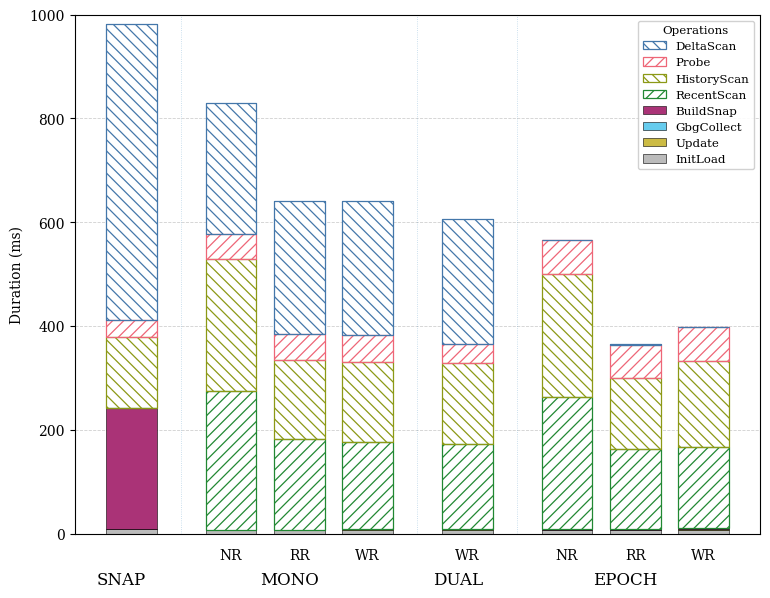

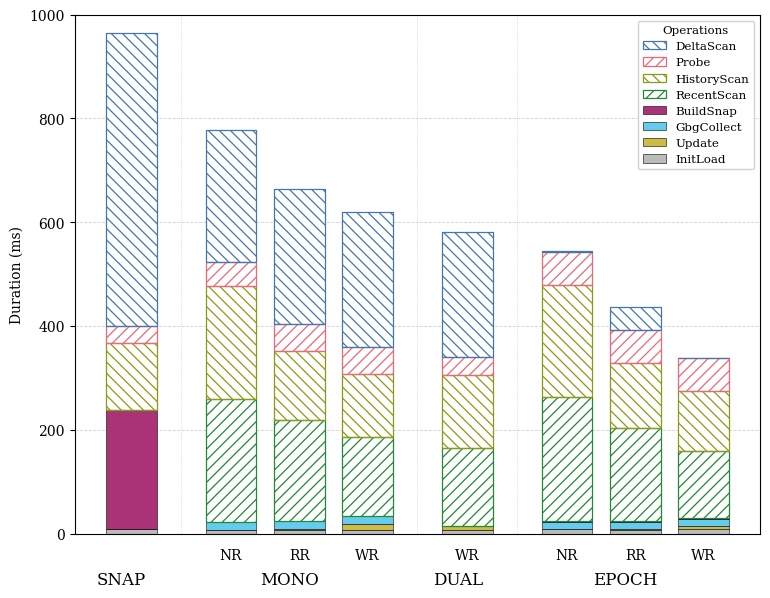

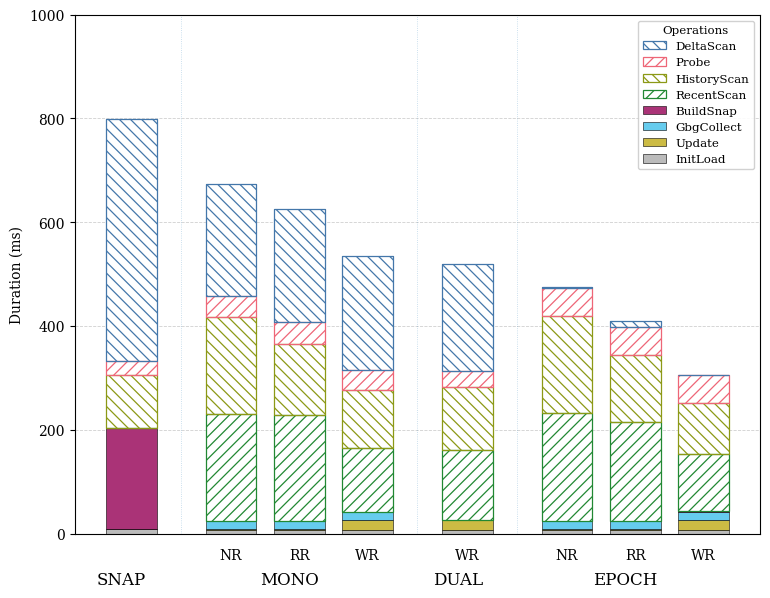

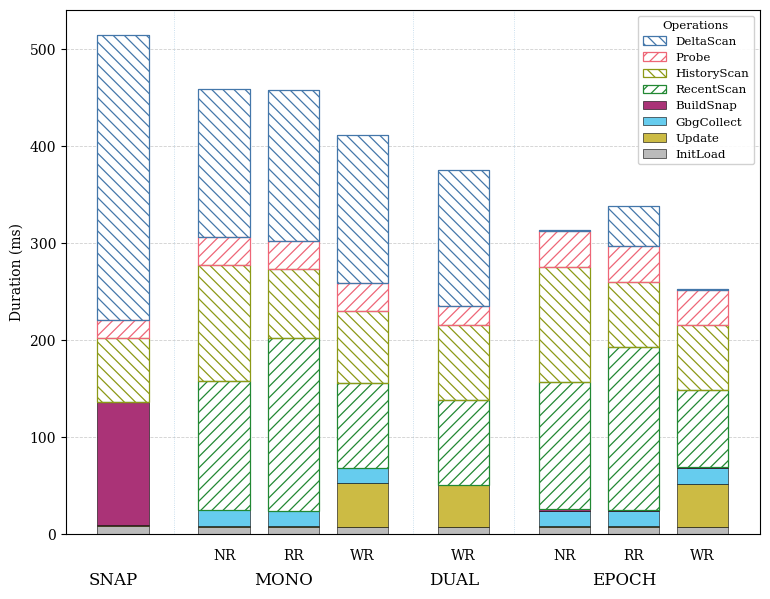

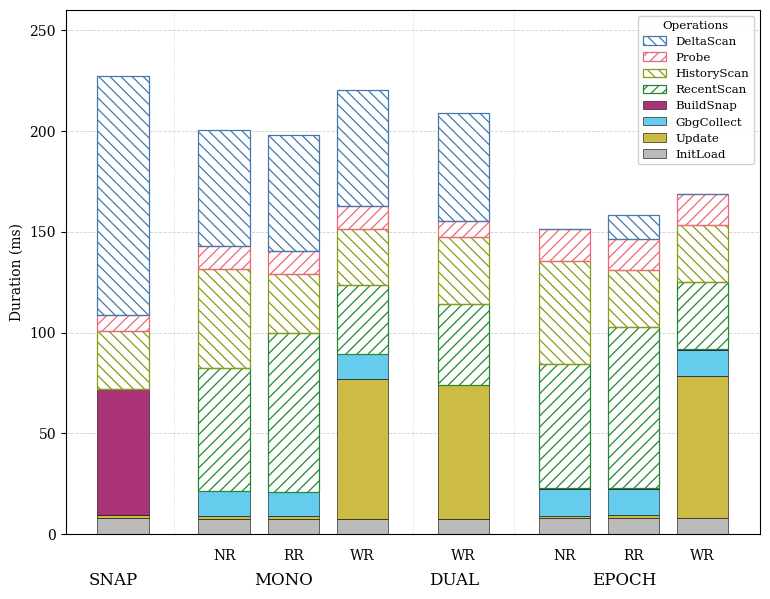

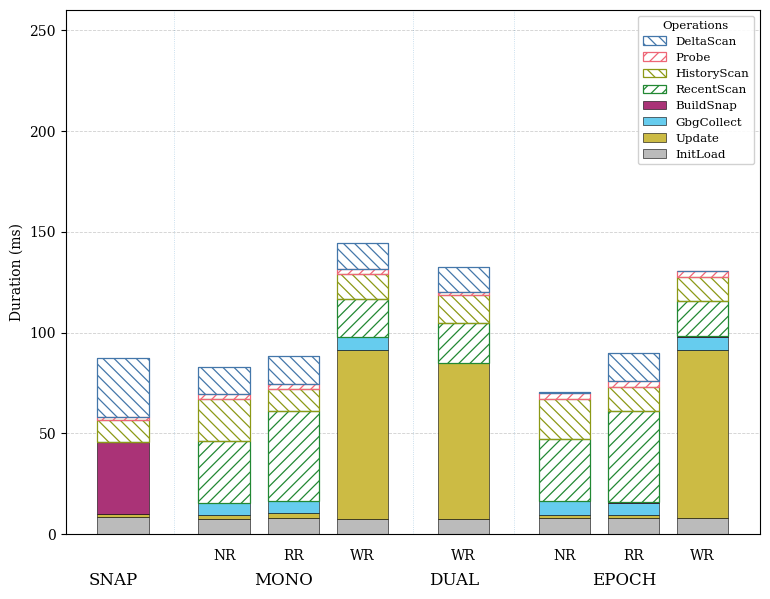

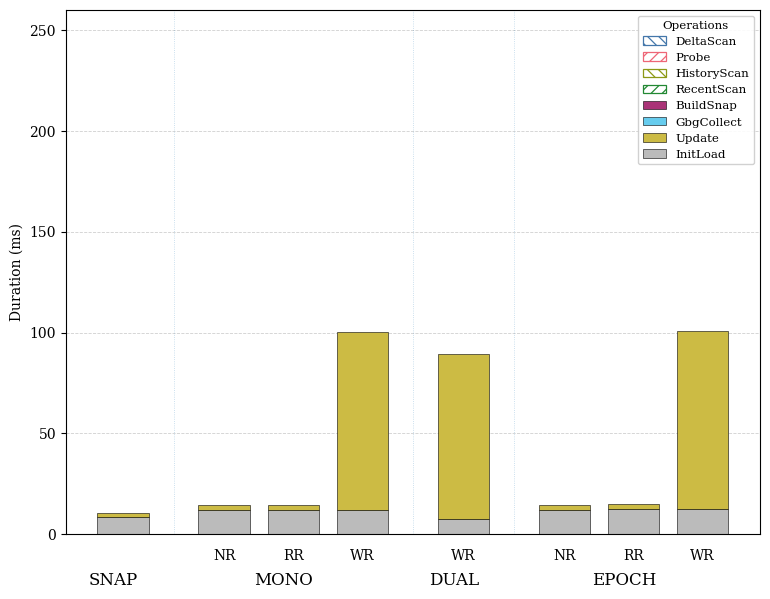

In [21]:
# Self-contained: paste into a cell and run.
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import pandas as pd

TX_MAP = {
    "MarkTs": "BuildSnap",
    "DelSc": "DeltaScan",
}



def draw_grouped_stacked_bar(df, title="R-heavy", subtitle="All Types", path = "output/"):
    # ORDER & DISPLAY NAMES
    table_order   = ["naive", "heap", "chain", "par"]  # data keys
    table_display = {"naive":"SNAP", "heap":"MONO", "chain":"DUAL", "par":"EPOCH"}

    repair_order = {
        "naive": [""],
        "heap":  ["No Repair", "Read Repair", "Write Repair"],
        "chain": ["Write Repair"],
        "par":   ["No Repair", "Read Repair", "Write Repair"],
    }
    repair_display = {"No Repair":"NR", "Read Repair":"RR", "Write Repair":"WR", "": ""}

    # STACK ORDER (bottom -> top)
    tx_order   = ["InitLoad", "Update", "GbgCollect", "BuildSnap", "RecentScan", "HistoryScan", "Probe", "DeltaScan"]
    # MarkTs = WRITE (solid)
    write_like = {"InitLoad", "Update", "GbgCollect", "BuildSnap"}
    read_like  = {"Probe", "RecentScan", "HistoryScan", "DeltaScan"}

    # Paul Tol "Bright" palette
    tol = {
        "blue":   "#4477AA",
        "cyan":   "#66CCEE",
        "green":  "#228833",
        "yellow": "#CCBB44",
        "red":    "#EE6677",
        "purple": "#AA3377",
        "grey":   "#BBBBBB",
        "darkgreen": "#8C9916",
    }
    # color_map = {
    #     "InitLoad":  tol["blue"],
    #     "Update":    tol["green"],
    #     "GbgCollect":tol["red"],
    #     "BuildSnap":    tol["purple"],
    #     "Probe":     tol["cyan"],
    #     "Scan":      tol["yellow"],
    #     "DeltaScan":     tol["grey"],
    # }
    color_map = {
        "InitLoad":  tol["grey"],
        "Update":    tol["yellow"],
        "GbgCollect":tol["cyan"],
        "BuildSnap":    tol["purple"],
        "Probe":     tol["red"],
        "RecentScan":      tol["green"],
        "HistoryScan":      tol["darkgreen"],
        "DeltaScan":     tol["blue"],
    }

    # READ hatch orientations (alternate): 
    # DelSc: backslash ( \ ), Scan: slash ( / ), Probe: backslash ( \ )
    hatch_read_map = {
        "DeltaScan": "\\\\\\",
        "Probe":  "///",
        "HistoryScan": "\\\\\\",
        "RecentScan": "///",
    }

    # Times New Roman
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"]  = ["Times New Roman", "Times", "Nimbus Roman No9 L", "DejaVu Serif"]
    plt.rcParams["hatch.linewidth"] = 0.9

    # pivot (ms) -> ms
    pvt = (
        df.pivot_table(index=["table_type","repair_type"],
                       columns="tx_type", values="duration_ms",
                       aggfunc="sum", fill_value=0.0)
        .reindex(columns=tx_order, fill_value=0.0)
    )


    # x positions (two-tier labels)
    bar_w = 0.58
    gap   = 0.36
    bar_x, minor_labels, major_centers, major_labels, combos = [], [], [], [], []
    x = 0.0
    for t in table_order:
        subs = repair_order[t]
        start = x
        for r in subs:
            bar_x.append(x)
            minor_labels.append(repair_display[r])  # NR/RR/WR
            combos.append((t, r))
            x += 0.78
        end = x - 1.0
        major_centers.append((start + end) / 2.0)
        major_labels.append(table_display[t])
        x += gap

    # slightly taller aspect ratio
    fig, ax = plt.subplots(figsize=(7.8, 6.0))
    fig.subplots_adjust(bottom=0.22)

    # stacked bars
    for i, (t, r) in enumerate(combos):
        row = pvt.loc[(t, r)] if (t, r) in pvt.index else pd.Series(0.0, index=tx_order)
        bottom = 0.0
        for tx in tx_order:
            v = float(row.get(tx, 0.0))
            if v <= 0:
                continue
            if tx in write_like:
                # WRITE: solid
                ax.bar(
                    bar_x[i], v, bottom=bottom, width=bar_w,
                    color=color_map[tx], edgecolor="black", linewidth=0.4, zorder=2
                )
            else:
                # READ: white base + colored hatch overlay (orientation per tx)
                ax.bar(
                    bar_x[i], v, bottom=bottom, width=bar_w,
                    color="white", edgecolor="black", linewidth=0.4, zorder=2
                )
                ax.bar(
                    bar_x[i], v, bottom=bottom, width=bar_w,
                    color="none", edgecolor=color_map[tx], linewidth=0.9,
                    hatch=hatch_read_map.get(tx, "///"), zorder=3
                )
            bottom += v

    # custom x labels (two lines, close to axis)
    ax.set_xticks([])
    for xi, lab in zip(bar_x, minor_labels):
        ax.text(xi, -0.028, lab, ha="center", va="top",
                transform=ax.get_xaxis_transform(), fontsize=10, clip_on=False)
    for xc, lab in zip(major_centers, major_labels):
        ax.text(xc, -0.072, lab, ha="center", va="top",
                transform=ax.get_xaxis_transform(), fontsize=12, clip_on=False)

    # separators between major groups
    for k in range(1, len(major_centers)):
        prev_end   = max([xx for xx,(tt,_) in zip(bar_x, combos) if tt == table_order[k-1]])
        next_start = min([xx for xx,(tt,_) in zip(bar_x, combos) if tt == table_order[k]])
        ax.axvline((prev_end + next_start)/2, linestyle=":", linewidth=0.6, alpha=0.3)

    # y-axis
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
    ax.set_ylabel("Duration (ms)")
    
    if title.startswith('R'):
        ax.set_ylim(top=1000.0)
    elif title.startswith('W'):
        ax.set_ylim(top=260.0)

    # Title (exactly as provided)
    # ax.set_title(title)

    # Legend (manual so READ shows hatch per-op, WRITE are solid), reversed order
    handles, labels = [], []
    for tx in tx_order[::-1]:
        if tx in write_like:
            patch = Patch(facecolor=color_map[tx], edgecolor="black", linewidth=0.4)
        else:
            patch = Patch(facecolor="white", edgecolor=color_map[tx],
                          hatch=hatch_read_map.get(tx, "///"), linewidth=0.9)
        handles.append(patch)
        labels.append(tx)

    # ax.legend(handles, labels, title="Operations",
    #           loc="upper right", framealpha=0.9, fontsize=9, title_fontsize=9)
    bbox_to_anchor = (1.0, 1.0)
    # if title.startswith('W') :
    #     bbox_to_anchor = (0.865, 1.0)

    # ax.legend(
    #     handles, labels, title="Operations",
    #     loc="upper right",
    #     bbox_to_anchor=bbox_to_anchor,   # 默认 (1,1)，往左移到 0.92，可微调
    #     framealpha=0.9,
    #     fontsize=9,
    #     title_fontsize=9
    # )
    ax.legend(
        handles, labels, title="Operations",
        loc="upper right",
        bbox_to_anchor=bbox_to_anchor,
        framealpha=0.9,
        fontsize=8.5,
        title_fontsize=8.5,
    )
    plt.tight_layout()
    
    plt.savefig(path + title + ".pdf", format="pdf")
    plt.show()

workload_levels = [
    "Analytical Only",
    "Extremely Analytical Heavy",
    "Analytical Heavy",
    "Hybrid",
    "Transactional Heavy",
    "Extremely Transactional Heavy",
    "Transactional Only"
]
workload_title_dict = {
    "Analytical Only": "RO",              # Read Only
    "Extremely Analytical Heavy": "RE",   # Read Extremely Heavy
    "Analytical Heavy": "RH",             # Read Heavy
    "Hybrid": "B",                        # Balanced
    "Transactional Heavy": "WH",          # Write Heavy
    "Extremely Transactional Heavy": "WE",# Write Extremely Heavy
    "Transactional Only": "WO"            # Write Only
}

TXN_NUM = 100

for wkld in workload_levels:
    df_name = "output/" + "(UNIFORM-ANALYTICAL) " + wkld + "_result.csv"
    # Load CSV into a DataFrame
    df = pd.read_csv(df_name)
    df["duration_ms"] = df["duration_ms"] / TXN_NUM
    # display(df)
    df["tx_type"] = df["tx_type"].replace(TX_MAP)
    df.loc[df["table_type"] == "naive", "repair_type"] = ""
    draw_grouped_stacked_bar(df, title=workload_title_dict[wkld], subtitle="All Types", path="output/")

# LINE PLOT

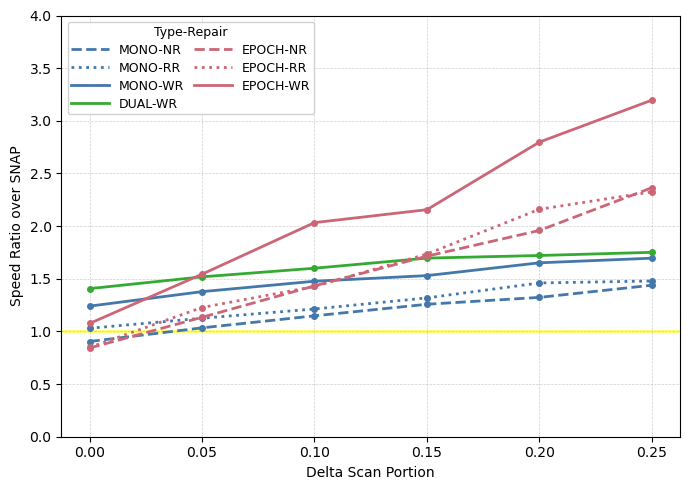

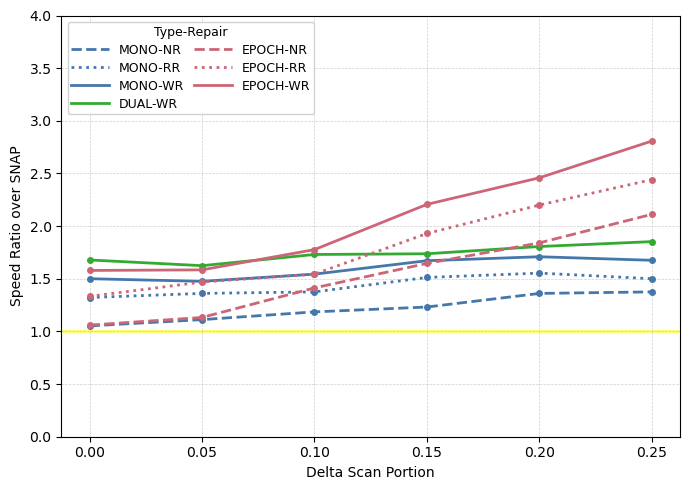

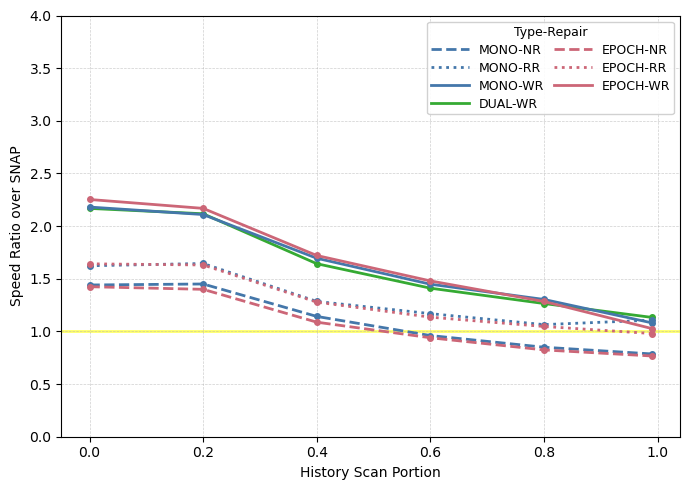

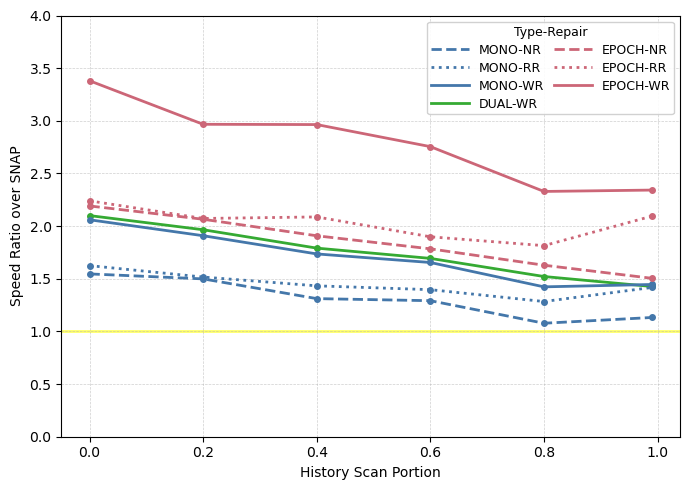

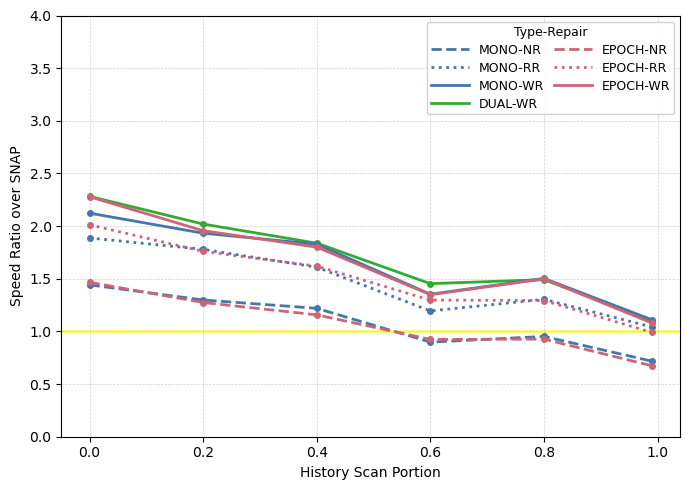

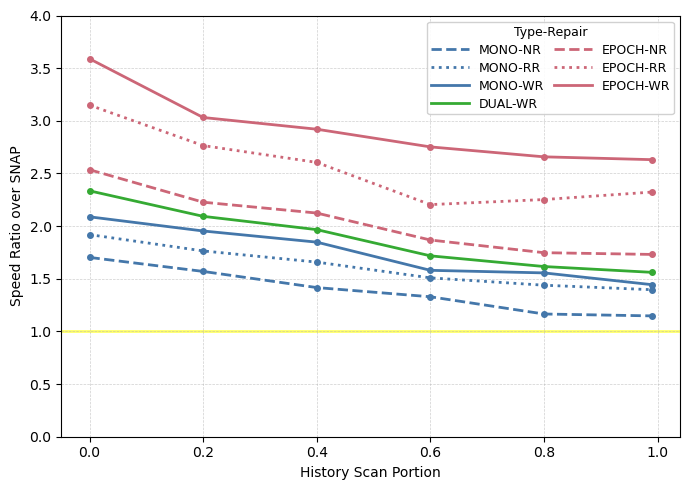

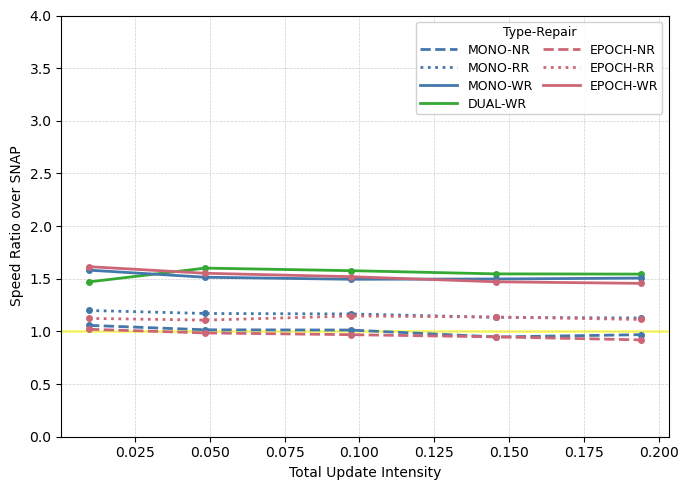

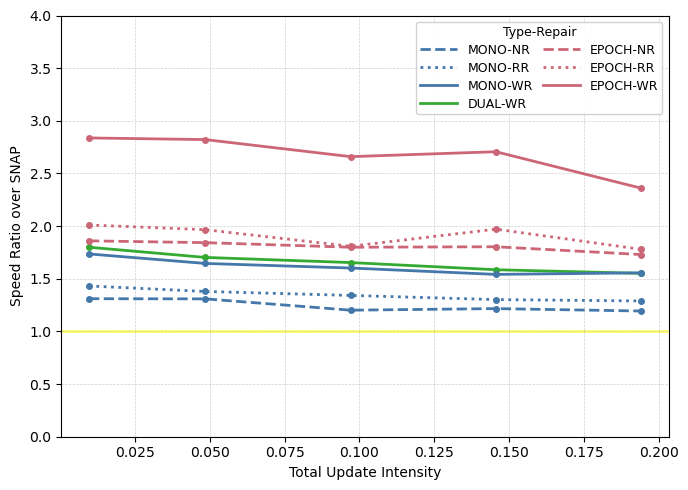

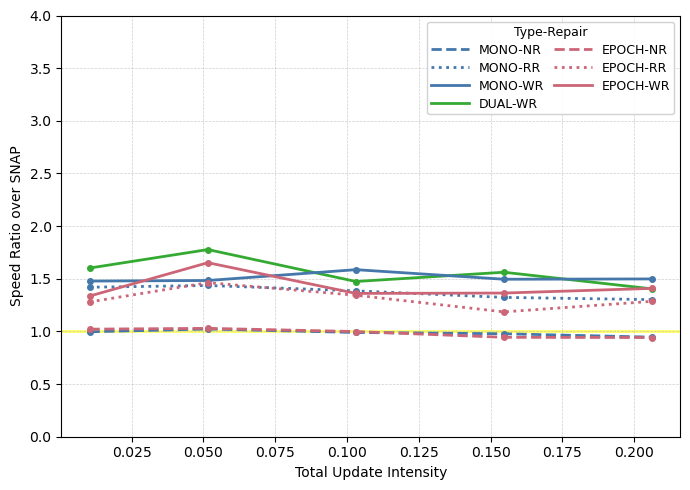

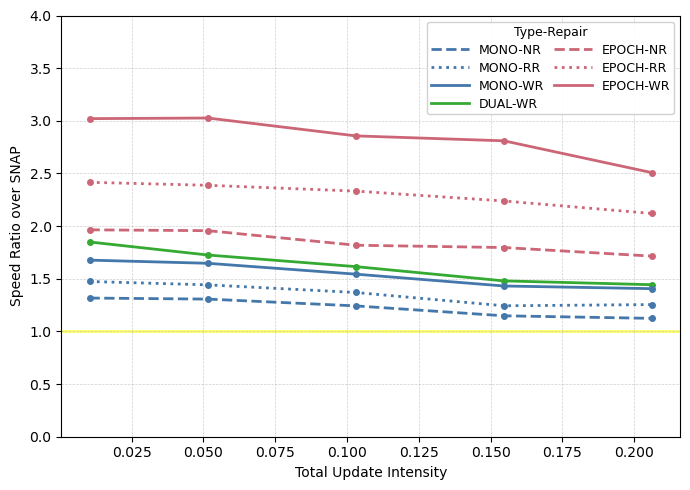

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def draw_line_plot(df, title, xaxis, xlabel, ylim, path="output/"):
    # === 映射与简化 ===
    table_display = {"heap": "MONO", "par": "EPOCH", "chain": "DUAL"}
    repair_display = {"No Repair": "NR", "Read Repair": "RR", "Write Repair": "WR"}

    df["table_type"] = df["table_type"].map(table_display)
    df["repair_type"] = df["repair_type"].map(repair_display)

    # === 配色与线型方案 ===
    color_map = {"MONO": "#4477AA", "EPOCH": "#CC6677", "DUAL": "#35AA33"}
    linestyle_map = {"NR": "dashed", "RR": "dotted", "WR": "-"}

    plt.figure(figsize=(7, 5))

    for table in df["table_type"].unique():
        subdf = df[df["table_type"] == table]
        for repair in subdf["repair_type"].unique():
            data = subdf[subdf["repair_type"] == repair]
            linestyle = linestyle_map[repair]
            if table == "DUAL":
                linestyle = "-"
            plt.plot(
                data[xaxis],
                data["speed_ratio_over_naive"],
                label=f"{table}-{repair}",
                color=color_map[table],
                linestyle=linestyle,
                linewidth=2,
                marker="o",
                markersize=4
            )

    plt.xlabel(xlabel)
    plt.ylabel("Speed Ratio over SNAP")
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.ylim(ylim)

    # === 自定义 legend 结构 ===
    legend_handles = []
    legend_labels = []

    # 按 repair_type 分组展示
    order = ["NR", "RR", "WR"]
    
    for table in ["MONO"]:
        for repair in order:
            legend_handles.append(Line2D(
                [0], [0],
                color=color_map[table],
                linestyle=linestyle_map[repair],
                linewidth=2
            ))
            legend_labels.append(f"{table}-{repair}")

    # 最后一行单独加 DUAL
    legend_handles.append(Line2D([0], [0], color=color_map["DUAL"], linestyle="-", linewidth=2))
    legend_labels.append("DUAL-WR")

    for table in ["EPOCH"]:
        for repair in order:
            legend_handles.append(Line2D(
                [0], [0],
                color=color_map[table],
                linestyle=linestyle_map[repair],
                linewidth=2
            ))
            legend_labels.append(f"{table}-{repair}")

    loc = "upper right"
    if xlabel == "Delta Scan Portion":
        loc = "upper left"

    plt.legend(
        legend_handles,
        legend_labels,
        title="Type-Repair",
        framealpha=0.9,
        fontsize=9,
        title_fontsize=9,
        ncol=2,                # 两列
        columnspacing=0.8,
        labelspacing=0.4,
        borderpad=0.3,
        handlelength=3,
        loc=loc
    )
    plt.axhline(
        y=1.0,
        color="#ffff00",
        linestyle="solid",
        linewidth=2,
        alpha=0.6,
        zorder=0               
    )

    plt.tight_layout()
    plt.savefig(path + title + ".pdf", format="pdf")
    plt.show()
WKLD_MAPS = {
    "DELTASC-RH": "output/(UNIFORM-ANALYTICAL) DELTA_SCAN_analyticalRatio0.8_result.csv",
    "DELTASC-RE": "output/(UNIFORM-ANALYTICAL) DELTA_SCAN_analyticalRatio0.95_result.csv",
    "REUSESC-RH-NoD": "output/(UNIFORM-ANALYTICAL) REUSE_OF_TIME_analyticalRatio0.8_deltaRatio0.0_result.csv",
    "REUSESC-RH-WithD": "output/(UNIFORM-ANALYTICAL) REUSE_OF_TIME_analyticalRatio0.8_deltaRatio0.25_result.csv",
    "REUSESC-RE-NoD": "output/(UNIFORM-ANALYTICAL) REUSE_OF_TIME_analyticalRatio0.95_deltaRatio0.0_result.csv",
    "REUSESC-RE-WithD": "output/(UNIFORM-ANALYTICAL) REUSE_OF_TIME_analyticalRatio0.95_deltaRatio0.25_result.csv",
    "UPDATE-RH-NoD":"output/(UNIFORM-ANALYTICAL) UPDATE_analyticalRatio0.8_removeDeltaTrue_result.csv",
    "UPDATE-RH-WithD":"output/(UNIFORM-ANALYTICAL) UPDATE_analyticalRatio0.8_removeDeltaFalse_result.csv",
    "UPDATE-RE-NoD":"output/(UNIFORM-ANALYTICAL) UPDATE_analyticalRatio0.95_removeDeltaTrue_result.csv",
    "UPDATE-RE-WithD":"output/(UNIFORM-ANALYTICAL) UPDATE_analyticalRatio0.95_removeDeltaFalse_result.csv",
}

XAXIS_MAPS = {
    "DELTASC-RH": "txn_delta_ratio",
    "DELTASC-RE": "txn_delta_ratio",
    "REUSESC-RH-NoD": "scan_reuse_ratio",
    "REUSESC-RH-WithD": "scan_reuse_ratio",
    "REUSESC-RE-NoD": "scan_reuse_ratio",
    "REUSESC-RE-WithD": "scan_reuse_ratio",
    "UPDATE-RH-NoD": "update_ratio",
    "UPDATE-RH-WithD": "update_ratio",
    "UPDATE-RE-NoD": "update_ratio",
    "UPDATE-RE-WithD": "update_ratio",
}

X_AXIS_TITLE = {
    "txn_delta_ratio": "Delta Scan Portion",
    "scan_reuse_ratio": "History Scan Portion",
    "update_ratio": "Total Update Intensity",
}

YLIM = {
    "txn_delta_ratio": (0.8, 3.6),
    "scan_reuse_ratio": (0.6, 4.0),
    "update_ratio": (0.75, 3.5),
}

for (title, df_path) in WKLD_MAPS.items():
    # Load CSV into a DataFrame
    df = pd.read_csv(df_path)
    # display(df)
    xaxis = XAXIS_MAPS[title]
    xlabel = X_AXIS_TITLE[xaxis]
    ylim = YLIM[xaxis]
    draw_line_plot(df, title=title, xaxis=xaxis, ylim = (0.0, 4.0), xlabel=xlabel)

# Heat Map

,table_type,repair_type,total_space,all_versions_space,valid_space,all_versions_ratio,valid_ratio,workload
0,SNAP,No Repair,17883987968,16539600000,751800000,0.924827,0.042038,R-Heavy
1,MONO,No Repair,862191616,778864800,751800000,0.903355,0.871964,R-Heavy
2,EPOCH,No Repair,1565786112,778864800,751800000,0.497427,0.480142,R-Heavy
3,DUAL,No Repair,879230976,778864800,751800000,0.885848,0.855065,R-Heavy
4,SNAP,No Repair,20322713600,18795000000,751800000,0.924827,0.036993,R-Extreme
5,MONO,No Repair,839647232,759318000,751800000,0.904330,0.895376,R-Extreme
6,EPOCH,No Repair,1666449408,759318000,751800000,0.455650,0.451139,R-Extreme
7,DUAL,No Repair,862191616,759318000,751800000,0.880684,0.871964,R-Extreme


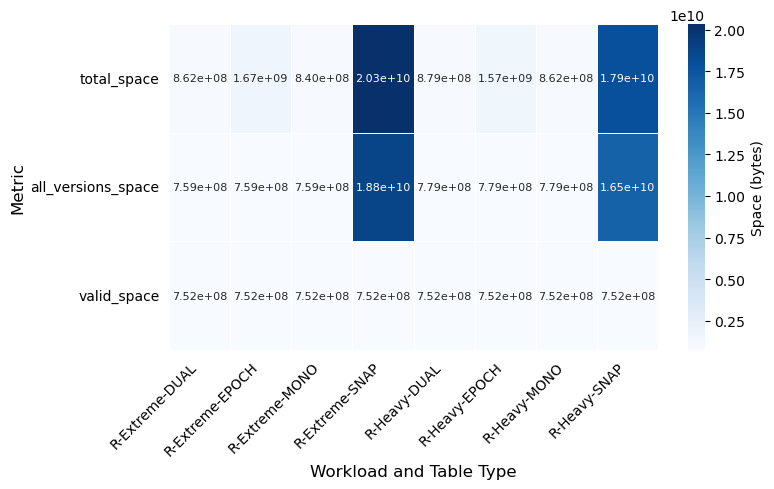

In [38]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def draw_heat_map(df, path = "output/"):
    pivot_table = df.pivot_table(
        index=["workload", "table_type"],
        values=["total_space", "all_versions_space", "valid_space"]
    )

    pivot_table = pivot_table[["total_space", "all_versions_space", "valid_space"]]

    pivot_table = pivot_table.T

    plt.figure(figsize=(8, 5))
    ax = sns.heatmap(
        pivot_table,
        annot=True,
        fmt=".2e",
        cmap="Blues",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Space (bytes)"},
        annot_kws={"fontsize":8} 
    )
    ax.tick_params(axis='x', which='both', bottom=False, top=False)
    ax.tick_params(axis='y', which='both', left=False, right=False)

    # plt.title("Space Usage Heatmap", fontsize=14, fontweight="bold")
    plt.ylabel("Metric", fontsize=12)
    plt.xlabel("Workload and Table Type", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(path + "SpaceStatistics" + ".pdf", format="pdf")
    plt.show()


TITLE_MAP = {
    "R-Heavy" : "(UNIFORM-ANALYTICAL) R-Heavy SpaceStatistics_spaceStatistics" + "_result.csv",
    "R-Extreme" : "(UNIFORM-ANALYTICAL) R-Extrme SpaceStatistics_spaceStatistics" + "_result.csv"
}
df_final = pd.DataFrame()
for title, name in TITLE_MAP.items():
    df_path = "output/" + name
    df = pd.read_csv(df_path)
    df["workload"] = title
    df_final = pd.concat([df_final, df], ignore_index=True)

display(df_final)

draw_heat_map(df_final)
